In [1]:
# !pip install torchmetrics optuna

In [2]:
import torchmetrics
import torchvision
import torchvision.transforms.v2 as T
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

In [3]:
from sklearn.datasets import load_sample_images

sample_images = load_sample_images()['images']
sample_images = np.stack(sample_images)
sample_images = torch.FloatTensor(sample_images)
sample_images /= 255

In [5]:
sample_images.shape

torch.Size([2, 427, 640, 3])

In [6]:
sample_images_permuted = sample_images.permute(0, 3, 1, 2)

print(sample_images_permuted.dtype, sample_images_permuted.shape)

torch.float32 torch.Size([2, 3, 427, 640])


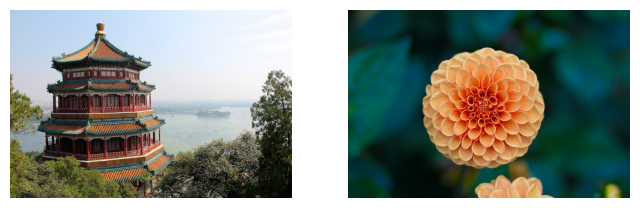

In [7]:
def plot_image(img_tensor):
    plt.imshow(img_tensor.permute(1,2,0))
    plt.axis('off')

plt.figure(figsize=(8, 4))
for index, img_tensor in enumerate(sample_images_permuted):
    plt.subplot(1, 2, index + 1)
    plot_image(img_tensor)

In [16]:
torch.prod(torch.tensor(sample_images_permuted.shape), dim=0)

tensor(1639680)

In [18]:
cropped_images = T.CenterCrop((70, 120))(sample_images_permuted)
cropped_images.shape

torch.Size([2, 3, 70, 120])

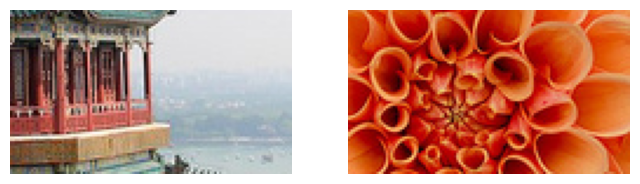

In [19]:
plt.figure(figsize=(8, 4))
for index, img_tensor in enumerate(cropped_images):
    plt.subplot(1, 2, index + 1)
    plot_image(img_tensor)

In [29]:
torch.manual_seed(42)

conv_layer = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=7)
print(cropped_images.shape)
print(conv_layer.weight.shape, conv_layer.padding,  conv_layer.stride)

fmaps = conv_layer(cropped_images)
print(fmaps.shape)

conv_layer2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=5)
fmaps2 = conv_layer2(fmaps)
print(fmaps2.shape)

torch.Size([2, 3, 70, 120])
torch.Size([32, 3, 7, 7]) (0, 0) (1, 1)
torch.Size([2, 32, 64, 114])
torch.Size([2, 64, 60, 110])


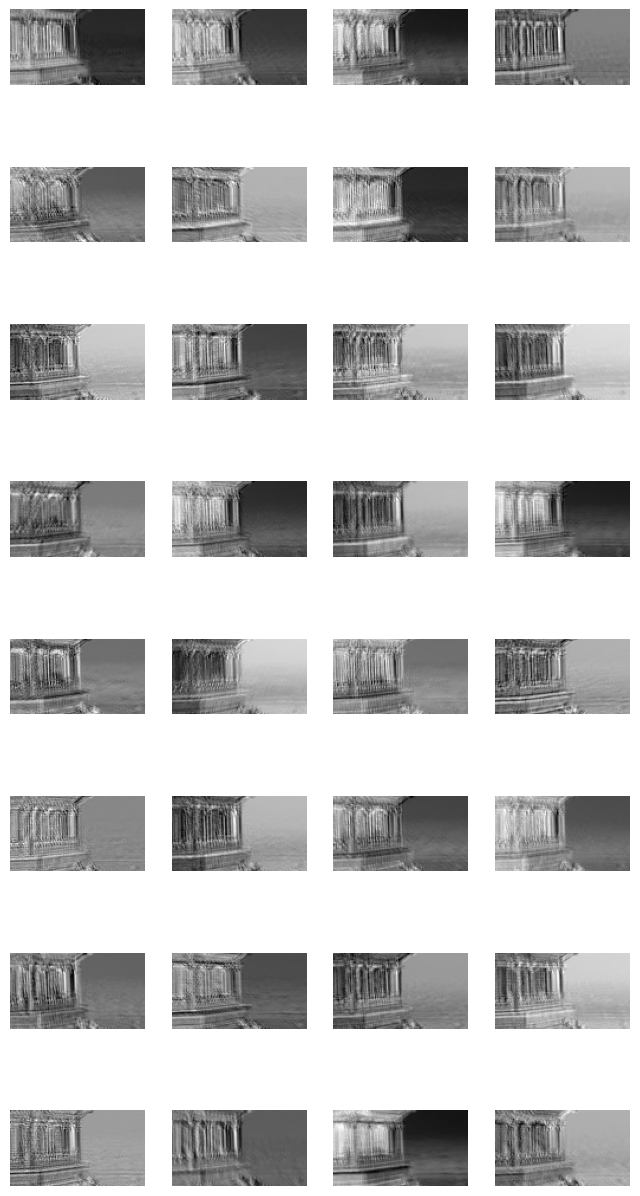

In [26]:
fig,axs = plt.subplots(8,4,figsize=(8,16))

for ind, ax in enumerate(axs.flat):
    ax.imshow(fmaps[0][ind].detach(), cmap='gray')
    ax.axis('off')

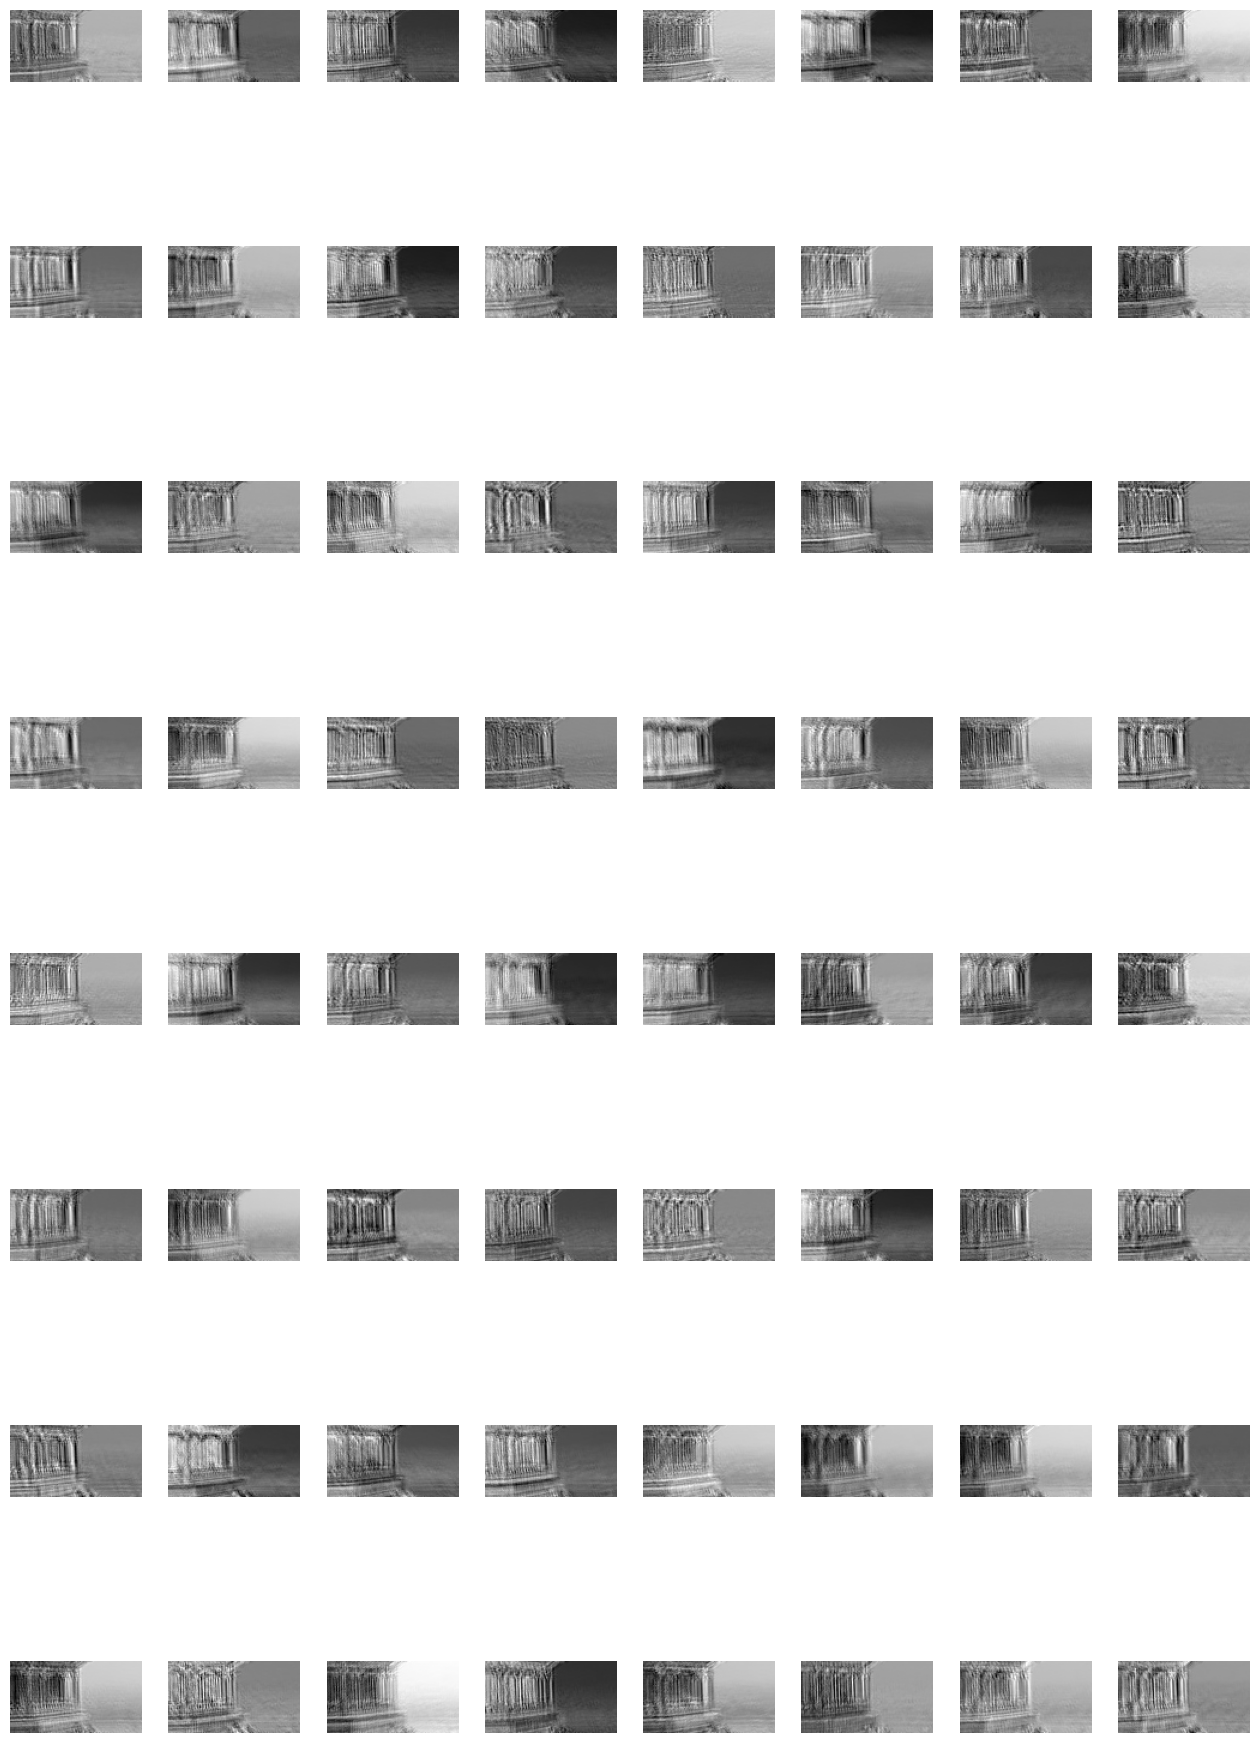

In [32]:
fig,axs = plt.subplots(8,8,figsize=(16,24))

for ind, ax in enumerate(axs.flat):
    ax.imshow(fmaps2[0][ind].detach(), cmap='gray')
    ax.axis('off')

torch.Size([2, 3, 70, 120])
torch.Size([2, 3, 35, 60])


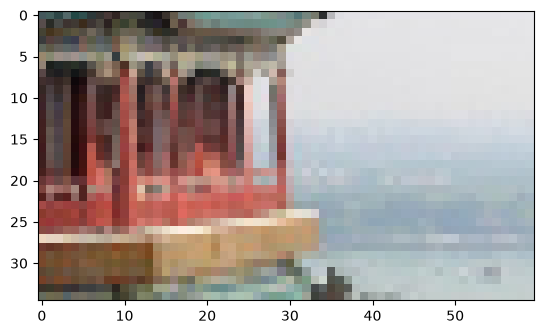

In [47]:
avg_pool = nn.AvgPool2d(kernel_size=2)
output_avg = avg_pool(cropped_images)
print(cropped_images.shape)
print(output_avg.shape)
plt.imshow(output_avg[0].permute(1, 2, 0))

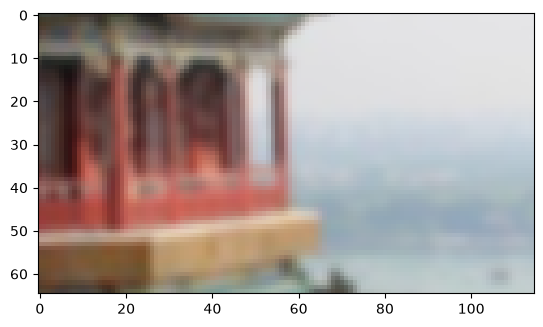

In [50]:
pooling_layer = nn.AvgPool2d(kernel_size=2, stride=1)

output = pooling_layer(cropped_images)
for i in range(4):
    output = pooling_layer(output)

plt.imshow(output[0].permute(1, 2, 0))

torch.Size([2, 3, 70, 120])
torch.Size([2, 3, 35, 60])


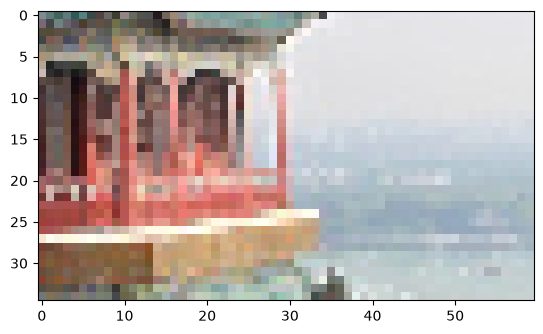

In [ ]:
max_pool = nn.MaxPool2d(kernel_size=2)
output_max = max_pool(cropped_images)
print(cropped_images.shape)
print(output_max.shape)
plt.imshow(output_max[0].permute(1, 2, 0))

torch.Size([2, 3, 65, 115])


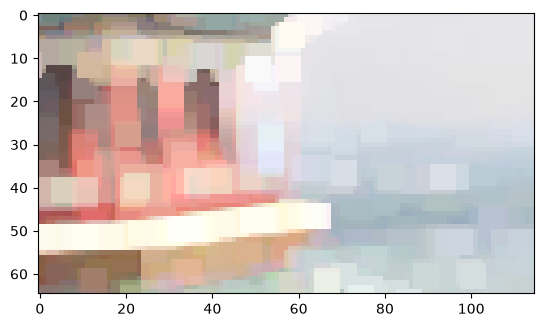

In [49]:
pooling_layer = nn.MaxPool2d(kernel_size=2, stride=1)

output = pooling_layer(cropped_images)
for i in range(4):
    output = pooling_layer(output)

print(output.shape)
plt.imshow(output[0].permute(1, 2, 0))

In [54]:
512*220

112640

In [ ]:
model = nn.Sequential(
    nn.Conv2d(3, out_channels=32, kernel_size=7), # (2, 3, 70, 120) -> (2, 32, 64, 114)
    nn.ReLU(),
    nn.Conv2d(32, 64, kernel_size=5), # (2, 64, 60, 110)
    nn.ReLU(),
    nn.Conv2d(64, 128, kernel_size=5), # (2, 128, 56, 106)
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2), # (2, 128, 28, 53)
    nn.Conv2d(128, 256, kernel_size=5), # (2, 256, 24, 49)
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2), # (2, 256, 12, 24)
    nn.Conv2d(256, 512, kernel_size=3), # (2, 512, 10, 22)
    nn.ReLU(),
    nn.Flatten(), # (2, 512, 10, 22) -> (2, 512, 220) -> (2, 112640)
    nn.Linear(112640, 100), 
    nn.ReLU(),
    nn.Linear(100, 200), 
    nn.ReLU(),
)

output = model(cropped_images)
output.shape

torch.Size([2, 200])

In [58]:
toTensor = T.Compose([
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True)
])


train_and_valid_data = torchvision.datasets.FashionMNIST(
    root="data", train=True, download=True, transform=toTensor)
test_data = torchvision.datasets.FashionMNIST(
    root="data", train=False, download=True, transform=toTensor)

100.0%
100.0%
100.0%
100.0%


In [59]:
torch.manual_seed(42)
train_data, valid_data = torch.utils.data.random_split(train_and_valid_data, [55_000, 5_000])

In [60]:
from torch.utils.data import DataLoader

torch.manual_seed(42)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

In [61]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

device

'mps'

In [66]:
next(iter(train_loader))[0].shape

torch.Size([32, 1, 28, 28])

In [67]:
model = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=64, kernel_size=7, padding="same"), # [32, 64, 28, 28]
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2), # [32, 64, 14, 14]
    nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding="same"), # [32, 128, 14, 14]
    nn.ReLU(),
    nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding="same"), # [32, 128, 14, 14]
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2), # [32, 128, 7, 7]
    nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding="same"), # [32, 256, 7, 7]
    nn.ReLU(),
    nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding="same"), # [32, 256, 7, 7]
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2), # [32, 256, 3, 3]
    nn.Flatten(), # [32, 2304]
    nn.Linear(in_features=2304, out_features=128),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(in_features=128, out_features=64),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(in_features=64, out_features=10),
).to(device)

In [69]:
from custom_utils import train, plot_history

n_epochs = 20
optimizer = torch.optim.AdamW(model.parameters())
criterion = nn.CrossEntropyLoss()
metric = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)
history = train(
	model,
	optimizer,
	criterion,
	metric,
	train_loader,
	valid_loader,
	n_epochs,
	warmup_scheduler=None,
	scheduler=None,
	patience=None,
	checkpoint_path='fashion_mnist_model.pt',
	clip_grad_norm=None,
    device=device
)

Epoch: 1/20, Train Loss: 0.833, Train Metric: 0.688, Valid Metric: 0.827, Time: 35.0s
	Checkpoint, valid metric: 0.827
Epoch: 2/20, Train Loss: 0.502, Train Metric: 0.824, Valid Metric: 0.871, Time: 29.21s
	Checkpoint, valid metric: 0.871
Epoch: 3/20, Train Loss: 0.423, Train Metric: 0.855, Valid Metric: 0.885, Time: 29.5s
	Checkpoint, valid metric: 0.885
Epoch: 4/20, Train Loss: 0.374, Train Metric: 0.872, Valid Metric: 0.894, Time: 27.77s
	Checkpoint, valid metric: 0.894
Epoch: 5/20, Train Loss: 0.334, Train Metric: 0.887, Valid Metric: 0.899, Time: 26.9s
	Checkpoint, valid metric: 0.899
Epoch: 6/20, Train Loss: 0.311, Train Metric: 0.893, Valid Metric: 0.902, Time: 28.14s
	Checkpoint, valid metric: 0.902
Epoch: 7/20, Train Loss: 0.289, Train Metric: 0.901, Valid Metric: 0.899, Time: 27.57s
Epoch: 8/20, Train Loss: 0.273, Train Metric: 0.908, Valid Metric: 0.905, Time: 29.23s
	Checkpoint, valid metric: 0.905
Epoch: 9/20, Train Loss: 0.254, Train Metric: 0.913, Valid Metric: 0.909, Ti

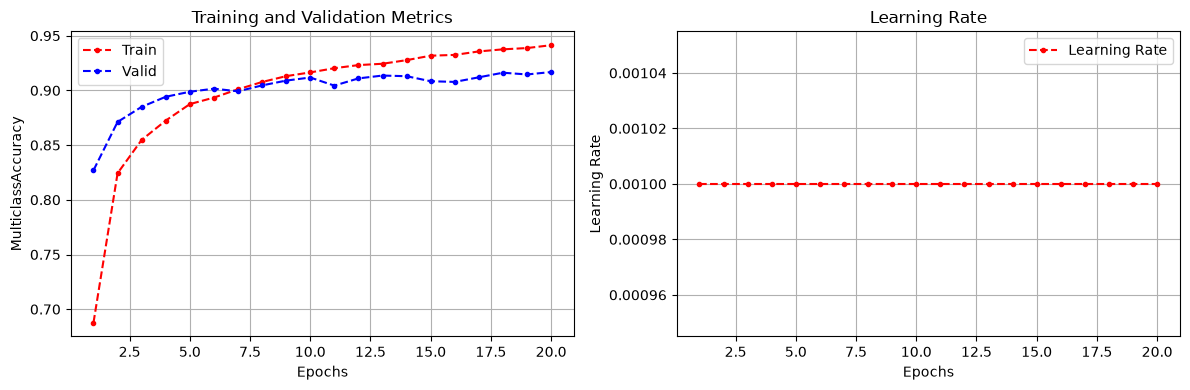

In [70]:
plot_history(history, metric)